In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTrain+ (1).txt to KDDTrain+ (1).txt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTest+ (1).txt to KDDTest+ (1).txt


In [ ]:
!ls

'KDDTest+ (1).txt'  'KDDTrain+ (1).txt'   sample_data


In [ ]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins",
"logged_in","num_compromised","root_shell","su_attempted",
"num_root","num_file_creations","num_shells","num_access_files",
"num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate",
"srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
"dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
"dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate",
"dst_host_srv_rerror_rate","label","difficulty"
]

In [ ]:
train = pd.read_csv("KDDTrain+ (1).txt", names = columns)
test = pd.read_csv("KDDTest+ (1).txt", names = columns)

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train.shape

(125973, 43)

In [ ]:
train.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
train.shape

(125973, 43)

In [ ]:
train['label'].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [ ]:
train['label'].value_counts().head()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931


In [ ]:
train['label'] = train['label'].apply(lambda x: 0 if str(x).strip() == 'normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if str(x).strip() == 'normal' else 1)

In [ ]:
train['label'].value_counts()

,count
label,
0,67343
1,58630


In [ ]:
train.drop('difficulty', axis=1, inplace=True)
test.drop('difficulty', axis=1, inplace=True)

In [ ]:
train.shape

(125973, 42)

In [ ]:
train = pd.get_dummies(train, columns=['protocol_type','service','flag'])
test = pd.get_dummies(test, columns=['protocol_type','service','flag'])

In [ ]:
train.shape

(125973, 123)

In [ ]:
X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']

In [ ]:
X_train.shape

(125973, 122)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

In [ ]:
X_test = scaler.transform(X_test)


In [ ]:
X_train.shape

(125973, 122)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train.shape


(125973, 122, 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

In [ ]:
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 120, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,393 (138.25 KB)

 Trainable params: 35,393 (138.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
print(type(X_train))
print(type(y_train))
print(type(X_test))
print(type(y_test))

print(X_train.shape)
print(y_train.shape)
print(X_train.dtype)
print(y_train.dtype)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(125973, 122, 1)
(125973,)
float32
float32


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 121s 37ms/step - accuracy: 0.9498 - loss: 0.1513 - val_accuracy: 0.9719 - val_loss: 0.0889
Epoch 2/5
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 143s 37ms/step - accuracy: 0.9734 - loss: 0.0865 - val_accuracy: 0.9779 - val_loss: 0.0699
Epoch 3/5
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 114s 36ms/step - accuracy: 0.9752 - loss: 0.0743 - val_accuracy: 0.9802 - val_loss: 0.0551
Epoch 4/5
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 144s 37ms/step - accuracy: 0.9783 - loss: 0.0628 - val_accuracy: 0.9798 - val_loss: 0.0561
Epoch 5/5
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 123s 39ms/step - accuracy: 0.9805 - loss: 0.0560 - val_accuracy: 0.9822 - val_loss: 0.0538


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

705/705 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7671 - loss: 0.9857
Test Accuracy: 0.7670777440071106


In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

705/705 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [ ]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.9191729323308271
Recall: 0.6477830593002416
F1 Score: 0.7599762307446176


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[8980  731]
 [4520 8313]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.92      0.77      9711
         1.0       0.92      0.65      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.77     22544



In [ ]:
import tensorflow as tf

In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy()

def fgsm_attack(model, x, y, epsilon):
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        prediction = model(x_tensor)
        loss = loss_object(y_tensor, prediction)

    gradient = tape.gradient(loss, x_tensor)
    signed_grad = tf.sign(gradient)

    x_adv = x_tensor + epsilon * signed_grad
    x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()

In [ ]:
X_test_small = X_test[:500]
y_test_small = y_test[:500]
epsilon = 0.01
X_test_fgsm = fgsm_attack(model, X_test_small, y_test_small, epsilon)

In [ ]:
fgsm_loss, fgsm_accuracy = model.evaluate(X_test_fgsm, y_test_small)
print("FGSM Test Accuracy:", fgsm_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7640 - loss: 1.0403
FGSM Test Accuracy: 0.7639999985694885


In [ ]:
y_pred_fgsm = (model.predict(X_test_fgsm) > 0.5).astype("int32").ravel()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

print("FGSM Precision:", precision_score(y_test_small, y_pred_fgsm))
print("FGSM Recall:", recall_score(y_test_small, y_pred_fgsm))
print("FGSM F1-score:", f1_score(y_test_small, y_pred_fgsm))

cm_fgsm = confusion_matrix(y_test_small, y_pred_fgsm)
print(cm_fgsm)

FGSM Precision: 0.8768472906403941
FGSM Recall: 0.6568265682656826
FGSM F1-score: 0.7510548523206751
[[204  25]
 [ 93 178]]


In [ ]:
attack_indices = (y_test_small == 1)
predicted_attacks = y_pred_fgsm[attack_indices]

esr = ((predicted_attacks == 0).sum() / len(predicted_attacks)) * 100
print("FGSM ESR:", esr)

FGSM ESR: 34.31734317343174


In [ ]:
batch_size = 128
epsilon = 0.01

fgsm_batches = []

for i in range(0, len(X_test), batch_size):
    x_batch = X_test[i:i+batch_size]
    y_batch = y_test[i:i+batch_size]

    x_adv_batch = fgsm_attack(model, x_batch, y_batch, epsilon)
    fgsm_batches.append(x_adv_batch)

    if i % 2000 == 0:
        print(f"Processed {i} samples")

X_test_fgsm_full = np.concatenate(fgsm_batches, axis=0).astype("float32")

Processed 0 samples
Processed 16000 samples


In [ ]:
fgsm_loss_full, fgsm_accuracy_full = model.evaluate(X_test_fgsm_full, y_test, verbose=0)
print("Full FGSM Test Accuracy:", fgsm_accuracy_full)

Full FGSM Test Accuracy: 0.7439673542976379


In [ ]:
y_pred_fgsm_full = (model.predict(X_test_fgsm_full, batch_size=128, verbose=0) > 0.5).astype("int32").ravel()

In [ ]:
fgsm_precision_full = precision_score(y_test, y_pred_fgsm_full)
fgsm_recall_full = recall_score(y_test, y_pred_fgsm_full)
fgsm_f1_full = f1_score(y_test, y_pred_fgsm_full)
cm_fgsm_full = confusion_matrix(y_test, y_pred_fgsm_full)

print("FGSM Precision:", fgsm_precision_full)
print("FGSM Recall:", fgsm_recall_full)
print("FGSM F1-score:", fgsm_f1_full)
print(cm_fgsm_full)

FGSM Precision: 0.9061313700678707
FGSM Recall: 0.6138081508610613
FGSM F1-score: 0.7318591470779523
[[8895  816]
 [4956 7877]]


In [ ]:
attack_mask = (y_test == 1)
esr_full = ((y_pred_fgsm_full[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("Full FGSM ESR:", esr_full)

Full FGSM ESR: 38.61918491389387


In [ ]:
fgsm_results = pd.DataFrame([{
    "Condition": "Baseline CNN-LSTM on FGSM test",
    "Epsilon": epsilon,
    "Accuracy": fgsm_accuracy_full,
    "Precision": fgsm_precision_full,
    "Recall": fgsm_recall_full,
    "F1-score": fgsm_f1_full,
    "ESR": esr_full
}])

fgsm_results

,Condition,Epsilon,Accuracy,Precision,Recall,F1-score,ESR
0,Baseline CNN-LSTM on FGSM test,0.01,0.743967,0.906131,0.613808,0.731859,38.619185


In [ ]:
np.save("X_test_fgsm_full.npy", X_test_fgsm_full)
np.save("y_pred_fgsm_full.npy", y_pred_fgsm_full)

In [ ]:
def pgd_attack(model, x, y, epsilon=0.01, alpha=0.002, iterations=10):
    x_orig = tf.convert_to_tensor(x, dtype=tf.float32)
    x_adv = tf.identity(x_orig)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            prediction = model(x_adv)
            loss = loss_object(y_tensor, prediction)

        gradient = tape.gradient(loss, x_adv)
        signed_grad = tf.sign(gradient)

        # small iterative step
        x_adv = x_adv + alpha * signed_grad

        # project back into epsilon-ball around original input
        x_adv = tf.clip_by_value(x_adv, x_orig - epsilon, x_orig + epsilon)

        # keep valid normalized range
        x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()


In [ ]:
X_test_small = X_test[:500]
y_test_small = y_test[:500]

X_test_pgd = pgd_attack(model, X_test_small, y_test_small, epsilon=0.01, alpha=0.002, iterations=10)
print("PGD subset shape:", X_test_pgd.shape)

PGD subset shape: (500, 122, 1)


In [ ]:
pgd_loss, pgd_accuracy = model.evaluate(X_test_pgd, y_test_small, verbose=0)
print("PGD Test Accuracy:", pgd_accuracy)

PGD Test Accuracy: 0.7540000081062317


In [ ]:
y_pred_pgd = (model.predict(X_test_pgd, verbose=0) > 0.5).astype("int32").ravel()

print("PGD Precision:", precision_score(y_test_small, y_pred_pgd))
print("PGD Recall:", recall_score(y_test_small, y_pred_pgd))
print("PGD F1-score:", f1_score(y_test_small, y_pred_pgd))

cm_pgd = confusion_matrix(y_test_small, y_pred_pgd)
print(cm_pgd)

PGD Precision: 0.87
PGD Recall: 0.6420664206642066
PGD F1-score: 0.7388535031847133
[[203  26]
 [ 97 174]]


In [ ]:
attack_indices = (y_test_small == 1)
predicted_attacks = y_pred_pgd[attack_indices]

pgd_esr = ((predicted_attacks == 0).sum() / len(predicted_attacks)) * 100
print("PGD ESR:", pgd_esr)

PGD ESR: 35.79335793357934


In [ ]:
batch_size = 64
pgd_batches = []

for i in range(0, len(X_test), batch_size):
    x_batch = X_test[i:i+batch_size]
    y_batch = y_test[i:i+batch_size]

    x_adv_batch = pgd_attack(model, x_batch, y_batch, epsilon=0.01, alpha=0.002, iterations=10)
    pgd_batches.append(x_adv_batch)

    if i % 2000 == 0:
        print(f"Processed {i} samples")

X_test_pgd_full = np.concatenate(pgd_batches, axis=0).astype("float32")
print("Full PGD shape:", X_test_pgd_full.shape)

Processed 0 samples
Processed 8000 samples
Processed 16000 samples
Full PGD shape: (22544, 122, 1)


In [ ]:
pgd_loss_full, pgd_accuracy_full = model.evaluate(X_test_pgd_full, y_test, verbose=0)
print("Full PGD Accuracy:", pgd_accuracy_full)

Full PGD Accuracy: 0.7375354766845703


In [ ]:
y_pred_pgd_full = (model.predict(X_test_pgd_full, batch_size=128, verbose=0) > 0.5).astype("int32").ravel()

In [ ]:
pgd_precision_full = precision_score(y_test, y_pred_pgd_full)
pgd_recall_full = recall_score(y_test, y_pred_pgd_full)
pgd_f1_full = f1_score(y_test, y_pred_pgd_full)
cm_pgd_full = confusion_matrix(y_test, y_pred_pgd_full)

print("PGD Precision:", pgd_precision_full)
print("PGD Recall:", pgd_recall_full)
print("PGD F1-score:", pgd_f1_full)
print(cm_pgd_full)

PGD Precision: 0.9022801302931596
PGD Recall: 0.6043793345281696
PGD F1-score: 0.7238788557562182
[[8871  840]
 [5077 7756]]


In [ ]:
attack_mask = (y_test == 1)
pgd_esr_full = ((y_pred_pgd_full[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("Full PGD ESR:", pgd_esr_full)


Full PGD ESR: 39.56206654718304


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (125973, 122, 1)
y_train: (125973,)
X_test: (22544, 122, 1)
y_test: (22544,)


In [ ]:
model.save("baseline_clean.keras")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

def build_hybrid_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(64))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
import tensorflow as tf
import numpy as np

loss_object = tf.keras.losses.BinaryCrossentropy()

def fgsm_attack(model, x, y, epsilon):
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        prediction = model(x_tensor)
        loss = loss_object(y_tensor, prediction)

    gradient = tape.gradient(loss, x_tensor)
    signed_grad = tf.sign(gradient)

    x_adv = x_tensor + epsilon * signed_grad
    x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()

In [ ]:
batch_size = 128
epsilon_train = 0.01

fgsm_train_batches = []

for i in range(0, len(X_train), batch_size):
    x_batch = X_train[i:i+batch_size]
    y_batch = y_train[i:i+batch_size]

    x_adv_batch = fgsm_attack(model, x_batch, y_batch, epsilon_train)
    fgsm_train_batches.append(x_adv_batch)

    if i % 5000 == 0:
        print(f"Processed {i} training samples")

X_train_fgsm = np.concatenate(fgsm_train_batches, axis=0).astype("float32")

print("X_train_fgsm shape:", X_train_fgsm.shape)

Processed 0 training samples
Processed 80000 training samples
X_train_fgsm shape: (125973, 122, 1)


In [ ]:
X_train_mix_fgsm = np.concatenate([X_train, X_train_fgsm], axis=0)
y_train_mix_fgsm = np.concatenate([y_train, y_train], axis=0)

print("Mixed X shape:", X_train_mix_fgsm.shape)
print("Mixed y shape:", y_train_mix_fgsm.shape)

Mixed X shape: (251946, 122, 1)
Mixed y shape: (251946,)


In [ ]:
indices = np.random.permutation(len(X_train_mix_fgsm))
X_train_mix_fgsm = X_train_mix_fgsm[indices]
y_train_mix_fgsm = y_train_mix_fgsm[indices]

In [ ]:
fgsm_defended_model = build_hybrid_model((X_train.shape[1], X_train.shape[2]))

history_fgsm_def = fgsm_defended_model.fit(
    X_train_mix_fgsm,
    y_train_mix_fgsm,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 236s 37ms/step - accuracy: 0.9593 - loss: 0.1252 - val_accuracy: 0.9749 - val_loss: 0.0721
Epoch 2/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 229s 36ms/step - accuracy: 0.9786 - loss: 0.0611 - val_accuracy: 0.9817 - val_loss: 0.0528
Epoch 3/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 232s 37ms/step - accuracy: 0.9822 - loss: 0.0509 - val_accuracy: 0.9820 - val_loss: 0.0541
Epoch 4/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 258s 36ms/step - accuracy: 0.9846 - loss: 0.0443 - val_accuracy: 0.9830 - val_loss: 0.0507
Epoch 5/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 265s 37ms/step - accuracy: 0.9875 - loss: 0.0376 - val_accuracy: 0.9856 - val_loss: 0.0335


In [ ]:
fgsm_defended_model.save("fgsm_defended_model.keras")

In [ ]:
print(type(X_test), getattr(X_test, "shape", None), getattr(X_test, "dtype", None))
print(type(y_test), getattr(y_test, "shape", None), getattr(y_test, "dtype", None))

<class 'numpy.ndarray'> (22544, 122, 1) float32
<class 'pandas.core.series.Series'> (22544,) float32


In [ ]:
import numpy as np

X_test_eval = np.asarray(X_test).astype("float32")
y_test_eval = np.asarray(y_test).astype("float32").reshape(-1, 1)

print("X_test_eval:", X_test_eval.shape, X_test_eval.dtype)
print("y_test_eval:", y_test_eval.shape, y_test_eval.dtype)

X_test_eval: (22544, 122, 1) float32
y_test_eval: (22544, 1) float32


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_prob_clean_def = fgsm_defended_model.predict(X_test_eval, batch_size=128, verbose=0).ravel()
y_pred_clean_def = (y_prob_clean_def > 0.5).astype("int32")
y_true_clean_def = y_test_eval.ravel().astype("int32")

In [ ]:
clean_acc_def = accuracy_score(y_true_clean_def, y_pred_clean_def)
clean_prec_def = precision_score(y_true_clean_def, y_pred_clean_def)
clean_rec_def = recall_score(y_true_clean_def, y_pred_clean_def)
clean_f1_def = f1_score(y_true_clean_def, y_pred_clean_def)
cm_clean_def = confusion_matrix(y_true_clean_def, y_pred_clean_def)

print("FGSM-defended model Clean Accuracy:", clean_acc_def)
print("FGSM-defended model Clean Precision:", clean_prec_def)
print("FGSM-defended model Clean Recall:", clean_rec_def)
print("FGSM-defended model Clean F1-score:", clean_f1_def)
print(cm_clean_def)

print(classification_report(y_true_clean_def, y_pred_clean_def))

FGSM-defended model Clean Accuracy: 0.7459634492547906
FGSM-defended model Clean Precision: 0.9238845144356955
FGSM-defended model Clean Recall: 0.6034442453050729
FGSM-defended model Clean F1-score: 0.7300494932830545
[[9073  638]
 [5089 7744]]
              precision    recall  f1-score   support

           0       0.64      0.93      0.76      9711
           1       0.92      0.60      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.74     22544



In [ ]:
X_test_fgsm_eval = np.asarray(X_test_fgsm_full).astype("float32")

In [ ]:
y_prob_fgsm_def = fgsm_defended_model.predict(X_test_fgsm_eval, batch_size=128, verbose=0).ravel()
y_pred_fgsm_def = (y_prob_fgsm_def > 0.5).astype("int32")
y_true_fgsm_def = y_test_eval.ravel().astype("int32")

In [ ]:
fgsm_acc_def = accuracy_score(y_true_fgsm_def, y_pred_fgsm_def)
fgsm_prec_def = precision_score(y_true_fgsm_def, y_pred_fgsm_def)
fgsm_rec_def = recall_score(y_true_fgsm_def, y_pred_fgsm_def)
fgsm_f1_def = f1_score(y_true_fgsm_def, y_pred_fgsm_def)
cm_fgsm_def = confusion_matrix(y_true_fgsm_def, y_pred_fgsm_def)

print("FGSM-defended model on FGSM Accuracy:", fgsm_acc_def)
print("FGSM-defended model on FGSM Precision:", fgsm_prec_def)
print("FGSM-defended model on FGSM Recall:", fgsm_rec_def)
print("FGSM-defended model on FGSM F1-score:", fgsm_f1_def)
print(cm_fgsm_def)

FGSM-defended model on FGSM Accuracy: 0.738999290276792
FGSM-defended model on FGSM Precision: 0.9217138002184732
FGSM-defended model on FGSM Recall: 0.5917556300163641
FGSM-defended model on FGSM F1-score: 0.7207668944570995
[[9066  645]
 [5239 7594]]


In [ ]:
attack_mask = (y_true_fgsm_def == 1)
fgsm_esr_def = ((y_pred_fgsm_def[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("FGSM-defended model FGSM ESR:", fgsm_esr_def)

FGSM-defended model FGSM ESR: 40.824436998363595


In [ ]:
X_test_pgd_eval = np.asarray(X_test_pgd_full).astype("float32")

In [ ]:
y_prob_pgd_def = fgsm_defended_model.predict(X_test_pgd_eval, batch_size=128, verbose=0).ravel()
y_pred_pgd_def = (y_prob_pgd_def > 0.5).astype("int32")
y_true_pgd_def = y_test_eval.ravel().astype("int32")

In [ ]:
pgd_acc_def = accuracy_score(y_true_pgd_def, y_pred_pgd_def)
pgd_prec_def = precision_score(y_true_pgd_def, y_pred_pgd_def)
pgd_rec_def = recall_score(y_true_pgd_def, y_pred_pgd_def)
pgd_f1_def = f1_score(y_true_pgd_def, y_pred_pgd_def)
cm_pgd_def = confusion_matrix(y_true_pgd_def, y_pred_pgd_def)

print("FGSM-defended model on PGD Accuracy:", pgd_acc_def)
print("FGSM-defended model on PGD Precision:", pgd_prec_def)
print("FGSM-defended model on PGD Recall:", pgd_rec_def)
print("FGSM-defended model on PGD F1-score:", pgd_f1_def)
print(cm_pgd_def)

FGSM-defended model on PGD Accuracy: 0.7400195173882186
FGSM-defended model on PGD Precision: 0.9217275586740866
FGSM-defended model on PGD Recall: 0.5937037325644822
FGSM-defended model on PGD F1-score: 0.7222143229536945
[[9064  647]
 [5214 7619]]


In [ ]:
attack_mask = (y_true_pgd_def == 1)
pgd_esr_def = ((y_pred_pgd_def[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("FGSM-defended model PGD ESR:", pgd_esr_def)

FGSM-defended model PGD ESR: 40.62962674355178


In [ ]:
batch_size = 64
epsilon_train = 0.01
alpha_train = 0.002
iterations_train = 10

pgd_train_batches = []

for i in range(0, len(X_train), batch_size):
    x_batch = X_train[i:i+batch_size]
    y_batch = y_train[i:i+batch_size]

    x_adv_batch = pgd_attack(
        model,
        x_batch,
        y_batch,
        epsilon=epsilon_train,
        alpha=alpha_train,
        iterations=iterations_train
    )
    pgd_train_batches.append(x_adv_batch)

    if i % 5000 == 0:
        print(f"Processed {i} training samples")

X_train_pgd = np.concatenate(pgd_train_batches, axis=0).astype("float32")

print("X_train_pgd shape:", X_train_pgd.shape)


Processed 0 training samples
Processed 40000 training samples
Processed 80000 training samples
Processed 120000 training samples
X_train_pgd shape: (125973, 122, 1)


In [ ]:
X_train_mix_pgd = np.concatenate([X_train, X_train_pgd], axis=0)
y_train_mix_pgd = np.concatenate([y_train, y_train], axis=0)

print("Mixed PGD X shape:", X_train_mix_pgd.shape)
print("Mixed PGD y shape:", y_train_mix_pgd.shape)

Mixed PGD X shape: (251946, 122, 1)
Mixed PGD y shape: (251946,)


In [ ]:
indices = np.random.permutation(len(X_train_mix_pgd))
X_train_mix_pgd = X_train_mix_pgd[indices]
y_train_mix_pgd = y_train_mix_pgd[indices]

In [ ]:
pgd_defended_model = build_hybrid_model((X_train.shape[1], X_train.shape[2]))

history_pgd_def = pgd_defended_model.fit(
    X_train_mix_pgd,
    y_train_mix_pgd,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 233s 37ms/step - accuracy: 0.9637 - loss: 0.1136 - val_accuracy: 0.9764 - val_loss: 0.0722
Epoch 2/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 265s 37ms/step - accuracy: 0.9780 - loss: 0.0656 - val_accuracy: 0.9811 - val_loss: 0.0511
Epoch 3/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 263s 37ms/step - accuracy: 0.9815 - loss: 0.0540 - val_accuracy: 0.9845 - val_loss: 0.0443
Epoch 4/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 234s 37ms/step - accuracy: 0.9831 - loss: 0.0478 - val_accuracy: 0.9852 - val_loss: 0.0432
Epoch 5/5
6299/6299 ━━━━━━━━━━━━━━━━━━━━ 234s 37ms/step - accuracy: 0.9855 - loss: 0.0410 - val_accuracy: 0.9869 - val_loss: 0.0363


In [ ]:
pgd_defended_model.save("pgd_defended_model.keras")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X_test_eval = np.asarray(X_test).astype("float32")
y_test_eval = np.asarray(y_test).astype("float32").reshape(-1, 1)

y_prob_clean_pgd_def = pgd_defended_model.predict(X_test_eval, batch_size=128, verbose=0).ravel()
y_pred_clean_pgd_def = (y_prob_clean_pgd_def > 0.5).astype("int32")
y_true_clean_pgd_def = y_test_eval.ravel().astype("int32")

In [ ]:
clean_acc_pgd_def = accuracy_score(y_true_clean_pgd_def, y_pred_clean_pgd_def)
clean_prec_pgd_def = precision_score(y_true_clean_pgd_def, y_pred_clean_pgd_def)
clean_rec_pgd_def = recall_score(y_true_clean_pgd_def, y_pred_clean_pgd_def)
clean_f1_pgd_def = f1_score(y_true_clean_pgd_def, y_pred_clean_pgd_def)
cm_clean_pgd_def = confusion_matrix(y_true_clean_pgd_def, y_pred_clean_pgd_def)

print("PGD-defended model Clean Accuracy:", clean_acc_pgd_def)
print("PGD-defended model Clean Precision:", clean_prec_pgd_def)
print("PGD-defended model Clean Recall:", clean_rec_pgd_def)
print("PGD-defended model Clean F1-score:", clean_f1_pgd_def)
print(cm_clean_pgd_def)

print(classification_report(y_true_clean_pgd_def, y_pred_clean_pgd_def))

PGD-defended model Clean Accuracy: 0.7519517388218595
PGD-defended model Clean Precision: 0.9433084363903514
PGD-defended model Clean Recall: 0.6003272812280839
PGD-defended model Clean F1-score: 0.7337142857142858
[[9248  463]
 [5129 7704]]
              precision    recall  f1-score   support

           0       0.64      0.95      0.77      9711
           1       0.94      0.60      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



In [ ]:
X_test_fgsm_eval = np.asarray(X_test_fgsm_full).astype("float32")

y_prob_fgsm_pgd_def = pgd_defended_model.predict(X_test_fgsm_eval, batch_size=128, verbose=0).ravel()
y_pred_fgsm_pgd_def = (y_prob_fgsm_pgd_def > 0.5).astype("int32")
y_true_fgsm_pgd_def = y_test_eval.ravel().astype("int32")

In [ ]:
fgsm_acc_pgd_def = accuracy_score(y_true_fgsm_pgd_def, y_pred_fgsm_pgd_def)
fgsm_prec_pgd_def = precision_score(y_true_fgsm_pgd_def, y_pred_fgsm_pgd_def)
fgsm_rec_pgd_def = recall_score(y_true_fgsm_pgd_def, y_pred_fgsm_pgd_def)
fgsm_f1_pgd_def = f1_score(y_true_fgsm_pgd_def, y_pred_fgsm_pgd_def)
cm_fgsm_pgd_def = confusion_matrix(y_true_fgsm_pgd_def, y_pred_fgsm_pgd_def)

print("PGD-defended model on FGSM Accuracy:", fgsm_acc_pgd_def)
print("PGD-defended model on FGSM Precision:", fgsm_prec_pgd_def)
print("PGD-defended model on FGSM Recall:", fgsm_rec_pgd_def)
print("PGD-defended model on FGSM F1-score:", fgsm_f1_pgd_def)
print(cm_fgsm_pgd_def)

PGD-defended model on FGSM Accuracy: 0.7430801987224982
PGD-defended model on FGSM Precision: 0.9204586169831601
PGD-defended model on FGSM Recall: 0.600561053533858
PGD-defended model on FGSM F1-score: 0.7268697538432519
[[9045  666]
 [5126 7707]]


In [ ]:
attack_mask = (y_true_fgsm_pgd_def == 1)
fgsm_esr_pgd_def = ((y_pred_fgsm_pgd_def[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("PGD-defended model FGSM ESR:", fgsm_esr_pgd_def)

PGD-defended model FGSM ESR: 39.9438946466142


In [ ]:
X_test_pgd_eval = np.asarray(X_test_pgd_full).astype("float32")

y_prob_pgd_pgd_def = pgd_defended_model.predict(X_test_pgd_eval, batch_size=128, verbose=0).ravel()
y_pred_pgd_pgd_def = (y_prob_pgd_pgd_def > 0.5).astype("int32")
y_true_pgd_pgd_def = y_test_eval.ravel().astype("int32")

In [ ]:
pgd_acc_pgd_def = accuracy_score(y_true_pgd_pgd_def, y_pred_pgd_pgd_def)
pgd_prec_pgd_def = precision_score(y_true_pgd_pgd_def, y_pred_pgd_pgd_def)
pgd_rec_pgd_def = recall_score(y_true_pgd_pgd_def, y_pred_pgd_pgd_def)
pgd_f1_pgd_def = f1_score(y_true_pgd_pgd_def, y_pred_pgd_pgd_def)
cm_pgd_pgd_def = confusion_matrix(y_true_pgd_pgd_def, y_pred_pgd_pgd_def)

print("PGD-defended model on PGD Accuracy:", pgd_acc_pgd_def)
print("PGD-defended model on PGD Precision:", pgd_prec_pgd_def)
print("PGD-defended model on PGD Recall:", pgd_rec_pgd_def)
print("PGD-defended model on PGD F1-score:", pgd_f1_pgd_def)
print(cm_pgd_pgd_def)

PGD-defended model on PGD Accuracy: 0.7438786373314408
PGD-defended model on PGD Precision: 0.923252188511812
PGD-defended model on PGD Recall: 0.5999376607184602
PGD-defended model on PGD F1-score: 0.7272813149442661
[[9071  640]
 [5134 7699]]


In [ ]:
attack_mask = (y_true_pgd_pgd_def == 1)
pgd_esr_pgd_def = ((y_pred_pgd_pgd_def[attack_mask] == 0).sum() / attack_mask.sum()) * 100
print("PGD-defended model PGD ESR:", pgd_esr_pgd_def)

PGD-defended model PGD ESR: 40.006233928153975


In [ ]:
final_results = pd.DataFrame([
    {
        "Condition": "Baseline on clean",
        "Accuracy": test_accuracy,
        "Precision": 0.9323952602623783,
        "Recall": 0.6867451102626042,
        "F1-score": 0.7909356069104779,
        "ESR": None
    },
    {
        "Condition": "Baseline on FGSM",
        "Accuracy": 0.7679657567423705,
        "Precision": 0.9188980716253443,
        "Recall": 0.6498090859502844,
        "F1-score": 0.7612744203030857,
        "ESR": 35.0109140497156
    },
    {
        "Condition": "Baseline on PGD",
        "Accuracy": 0.7072391767201916,
        "Precision": 0.9367904695164682,
        "Recall": 0.520844697264864,
        "F1-score": 0.6694711538461539,
        "ESR": 47.915530273513596
    },
    {
        "Condition": "FGSM-defended on FGSM",
        "Accuracy": fgsm_acc_def,
        "Precision": fgsm_prec_def,
        "Recall": fgsm_rec_def,
        "F1-score": fgsm_f1_def,
        "ESR": fgsm_esr_def
    },
    {
        "Condition": "FGSM-defended on PGD",
        "Accuracy": pgd_acc_def,
        "Precision": pgd_prec_def,
        "Recall": pgd_rec_def,
        "F1-score": pgd_f1_def,
        "ESR": pgd_esr_def
    },
    {
        "Condition": "PGD-defended on clean",
        "Accuracy": clean_acc_pgd_def,
        "Precision": clean_prec_pgd_def,
        "Recall": clean_rec_pgd_def,
        "F1-score": clean_f1_pgd_def,
        "ESR": None
    },
    {
        "Condition": "PGD-defended on FGSM",
        "Accuracy": fgsm_acc_pgd_def,
        "Precision": fgsm_prec_pgd_def,
        "Recall": fgsm_rec_pgd_def,
        "F1-score": fgsm_f1_pgd_def,
        "ESR": fgsm_esr_pgd_def
    },
    {
        "Condition": "PGD-defended on PGD",
        "Accuracy": pgd_acc_pgd_def,
        "Precision": pgd_prec_pgd_def,
        "Recall": pgd_rec_pgd_def,
        "F1-score": pgd_f1_pgd_def,
        "ESR": pgd_esr_pgd_def
    }
])

final_results

,Condition,Accuracy,Precision,Recall,F1-score,ESR
0,Baseline on clean,0.767078,0.932395,0.686745,0.790936,NaN
1,Baseline on FGSM,0.767966,0.918898,0.649809,0.761274,35.010914
2,Baseline on PGD,0.707239,0.936790,0.520845,0.669471,47.915530
3,FGSM-defended on FGSM,0.738999,0.921714,0.591756,0.720767,40.824437
4,FGSM-defended on PGD,0.740020,0.921728,0.593704,0.722214,40.629627
5,PGD-defended on clean,0.751952,0.943308,0.600327,0.733714,NaN
6,PGD-defended on FGSM,0.743080,0.920459,0.600561,0.726870,39.943895
7,PGD-defended on PGD,0.743879,0.923252,0.599938,0.727281,40.006234


In [ ]:
!ls


 baseline_clean.keras	    'KDDTrain+ (1).txt'         X_test_fgsm_full.npy
 fgsm_defended_model.keras   pgd_defended_model.keras   y_pred_fgsm_full.npy
'KDDTest+ (1).txt'	     sample_data


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test_eval = np.asarray(X_test).astype("float32")
y_test_eval = np.asarray(y_test).astype("int32").ravel()

print(X_test_eval.shape, y_test_eval.shape)

(22544, 122, 1) (22544,)


In [ ]:
def generate_fgsm_full(model, X_data, y_data, epsilon, batch_size=128):
    fgsm_batches = []

    for i in range(0, len(X_data), batch_size):
        x_batch = X_data[i:i+batch_size]
        y_batch = y_data[i:i+batch_size]

        x_adv_batch = fgsm_attack(model, x_batch, y_batch, epsilon)
        fgsm_batches.append(x_adv_batch)

    return np.concatenate(fgsm_batches, axis=0).astype("float32")

In [ ]:
epsilons = [0.01, 0.02, 0.03, 0.05]

In [ ]:
fgsm_sweep_results = []

for eps in epsilons:
    print(f"Running FGSM sweep for epsilon = {eps}")

    X_test_fgsm_eps = generate_fgsm_full(model, X_test_eval, y_test_eval, epsilon=eps, batch_size=128)

    y_prob = model.predict(X_test_fgsm_eps, batch_size=128, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    acc = accuracy_score(y_test_eval, y_pred)
    prec = precision_score(y_test_eval, y_pred)
    rec = recall_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred)

    attack_mask = (y_test_eval == 1)
    esr = ((y_pred[attack_mask] == 0).sum() / attack_mask.sum()) * 100

    fgsm_sweep_results.append({
        "Attack": "FGSM",
        "Epsilon": eps,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ESR": esr
    })

fgsm_sweep_results = pd.DataFrame(fgsm_sweep_results)
fgsm_sweep_results

Running FGSM sweep for epsilon = 0.01
Running FGSM sweep for epsilon = 0.02
Running FGSM sweep for epsilon = 0.03
Running FGSM sweep for epsilon = 0.05


,Attack,Epsilon,Accuracy,Precision,Recall,F1-score,ESR
0,FGSM,0.01,0.743967,0.906131,0.613808,0.731859,38.619185
1,FGSM,0.02,0.735140,0.898583,0.602743,0.721515,39.725707
2,FGSM,0.03,0.729507,0.892711,0.596509,0.715153,40.349100
3,FGSM,0.05,0.718240,0.883174,0.582015,0.701644,41.798488


In [ ]:
fgsm_sweep_results.to_csv("fgsm_epsilon_sweep.csv", index=False)

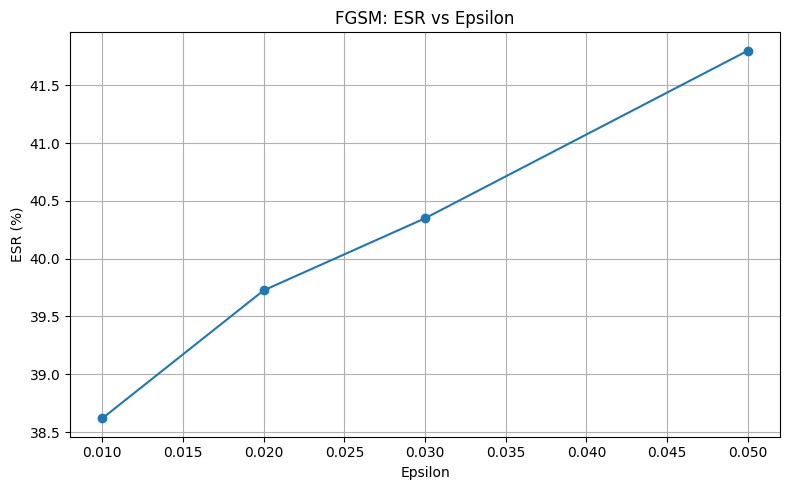

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(fgsm_sweep_results["Epsilon"], fgsm_sweep_results["ESR"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("ESR (%)")
plt.title("FGSM: ESR vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig("fgsm_esr_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

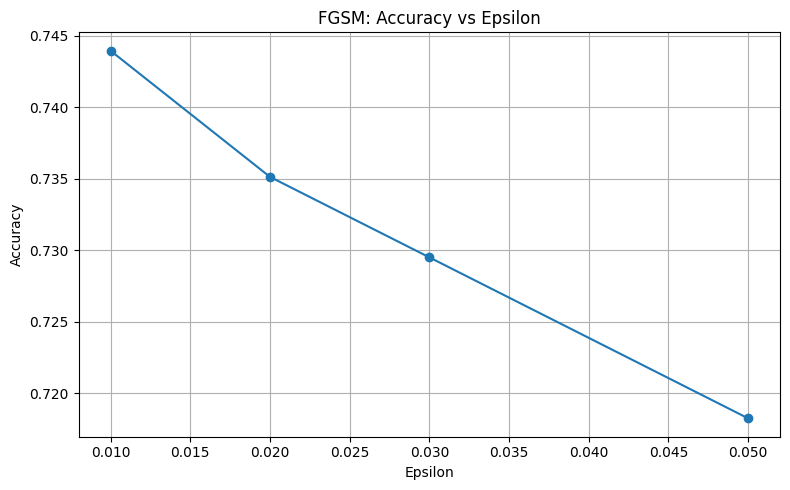

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fgsm_sweep_results["Epsilon"], fgsm_sweep_results["Accuracy"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM: Accuracy vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig("fgsm_accuracy_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

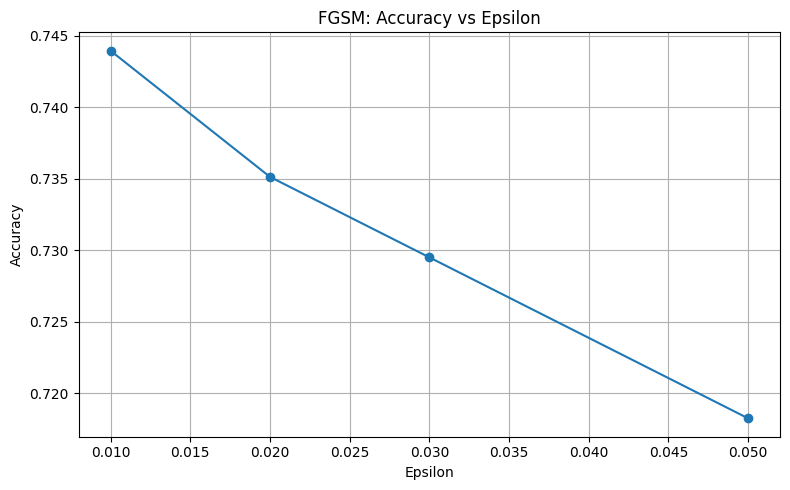

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fgsm_sweep_results["Epsilon"], fgsm_sweep_results["Accuracy"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM: Accuracy vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig("fgsm_accuracy_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def generate_pgd_full(model, X_data, y_data, epsilon, alpha=0.002, iterations=10, batch_size=64):
    pgd_batches = []

    for i in range(0, len(X_data), batch_size):
        x_batch = X_data[i:i+batch_size]
        y_batch = y_data[i:i+batch_size]

        x_adv_batch = pgd_attack(
            model,
            x_batch,
            y_batch,
            epsilon=epsilon,
            alpha=alpha,
            iterations=iterations
        )
        pgd_batches.append(x_adv_batch)

    return np.concatenate(pgd_batches, axis=0).astype("float32")

In [ ]:
pgd_sweep_results = []

for eps in epsilons:
    print(f"Running PGD sweep for epsilon = {eps}")

    X_test_pgd_eps = generate_pgd_full(
        model,
        X_test_eval,
        y_test_eval,
        epsilon=eps,
        alpha=0.002,
        iterations=10,
        batch_size=64
    )

    y_prob = model.predict(X_test_pgd_eps, batch_size=128, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    acc = accuracy_score(y_test_eval, y_pred)
    prec = precision_score(y_test_eval, y_pred)
    rec = recall_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred)

    attack_mask = (y_test_eval == 1)
    esr = ((y_pred[attack_mask] == 0).sum() / attack_mask.sum()) * 100

    pgd_sweep_results.append({
        "Attack": "PGD",
        "Epsilon": eps,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ESR": esr
    })

pgd_sweep_results = pd.DataFrame(pgd_sweep_results)
pgd_sweep_results

Running PGD sweep for epsilon = 0.01
Running PGD sweep for epsilon = 0.02
Running PGD sweep for epsilon = 0.03
Running PGD sweep for epsilon = 0.05


,Attack,Epsilon,Accuracy,Precision,Recall,F1-score,ESR
0,PGD,0.01,0.737535,0.902280,0.604379,0.723879,39.562067
1,PGD,0.02,0.726180,0.892874,0.589730,0.710310,41.027040
2,PGD,0.03,0.726180,0.892874,0.589730,0.710310,41.027040
3,PGD,0.05,0.726180,0.892874,0.589730,0.710310,41.027040


In [ ]:
pgd_sweep_results.to_csv("pgd_epsilon_sweep.csv", index=False)

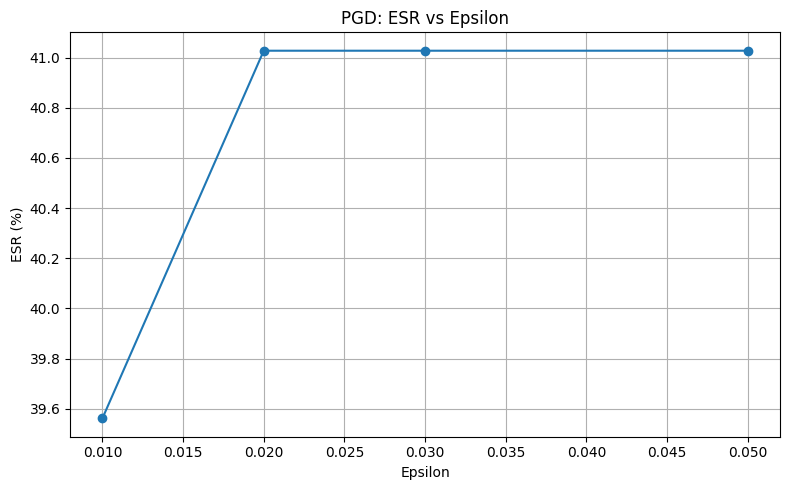

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(pgd_sweep_results["Epsilon"], pgd_sweep_results["ESR"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("ESR (%)")
plt.title("PGD: ESR vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig("pgd_esr_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

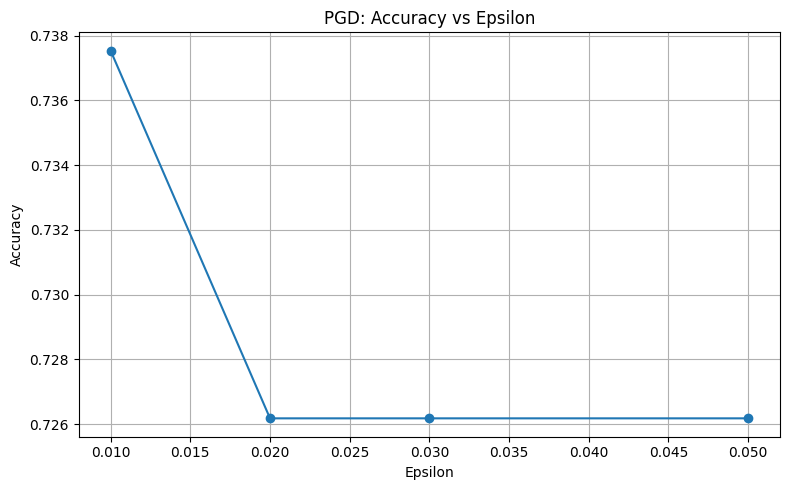

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(pgd_sweep_results["Epsilon"], pgd_sweep_results["Accuracy"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("PGD: Accuracy vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig("pgd_accuracy_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

In [ ]:
def build_tunable_model(input_shape, filters=64, lstm_units=64, dropout_rate=0.5, dense_units=32):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(lstm_units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
tuning_configs = [
    {"name": "config_1", "filters": 64, "lstm_units": 64, "dropout_rate": 0.5, "dense_units": 32, "batch_size": 32},
    {"name": "config_2", "filters": 32, "lstm_units": 64, "dropout_rate": 0.3, "dense_units": 32, "batch_size": 32},
    {"name": "config_3", "filters": 64, "lstm_units": 32, "dropout_rate": 0.5, "dense_units": 16, "batch_size": 64},
]

In [ ]:
tuning_results = []

for cfg in tuning_configs:
    print(f"Running {cfg['name']} ...")

    model_tune = build_tunable_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        filters=cfg["filters"],
        lstm_units=cfg["lstm_units"],
        dropout_rate=cfg["dropout_rate"],
        dense_units=cfg["dense_units"]
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        ModelCheckpoint(f"{cfg['name']}_best.keras", monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model_tune.fit(
        X_train, y_train,
        epochs=15,
        batch_size=cfg["batch_size"],
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    stopped_epoch = len(history.history["loss"])

    X_test_eval = np.asarray(X_test).astype("float32")
    y_test_eval = np.asarray(y_test).astype("int32").ravel()

    y_prob = model_tune.predict(X_test_eval, batch_size=128, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    test_acc = accuracy_score(y_test_eval, y_pred)
    test_prec = precision_score(y_test_eval, y_pred)
    test_rec = recall_score(y_test_eval, y_pred)
    test_f1 = f1_score(y_test_eval, y_pred)

    tuning_results.append({
        "Config": cfg["name"],
        "Filters": cfg["filters"],
        "LSTM_units": cfg["lstm_units"],
        "Dropout": cfg["dropout_rate"],
        "Dense_units": cfg["dense_units"],
        "Batch_size": cfg["batch_size"],
        "Best_val_accuracy": best_val_acc,
        "Best_val_loss": best_val_loss,
        "Epochs_run": stopped_epoch,
        "Test_accuracy": test_acc,
        "Test_precision": test_prec,
        "Test_recall": test_rec,
        "Test_f1": test_f1
    })

Running config_1 ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 120s 37ms/step - accuracy: 0.9437 - loss: 0.1723 - val_accuracy: 0.9608 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 2/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 116s 37ms/step - accuracy: 0.9707 - loss: 0.0908 - val_accuracy: 0.9752 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 3/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 0.9741 - loss: 0.0701 - val_accuracy: 0.9779 - val_loss: 0.0581 - learning_rate: 0.0010
Epoch 4/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 115s 36ms/step - accuracy: 0.9760 - loss: 0.0615 - val_accuracy: 0.9772 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 5/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 117s 37ms/step - accuracy: 0.9789 - loss: 0.0549 - val_accuracy: 0.9769 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 6/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 139s 36ms/step - accuracy: 0.9825 - loss: 0.0481 - val_accuracy: 0.9866 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 7/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 144s 37ms/step -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 108s 33ms/step - accuracy: 0.9409 - loss: 0.1797 - val_accuracy: 0.9684 - val_loss: 0.1046 - learning_rate: 0.0010
Epoch 2/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 109s 35ms/step - accuracy: 0.9712 - loss: 0.0933 - val_accuracy: 0.9729 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 3/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 110s 35ms/step - accuracy: 0.9756 - loss: 0.0766 - val_accuracy: 0.9781 - val_loss: 0.0658 - learning_rate: 0.0010
Epoch 4/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 140s 34ms/step - accuracy: 0.9763 - loss: 0.0670 - val_accuracy: 0.9811 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 5/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 109s 34ms/step - accuracy: 0.9795 - loss: 0.0559 - val_accuracy: 0.9844 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 6/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 104s 33ms/step - accuracy: 0.9823 - loss: 0.0496 - val_accuracy: 0.9858 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 7/15
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 142s 33ms/step -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 63s 38ms/step - accuracy: 0.9323 - loss: 0.2079 - val_accuracy: 0.9641 - val_loss: 0.1142 - learning_rate: 0.0010
Epoch 2/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.9656 - loss: 0.1080 - val_accuracy: 0.9739 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 3/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.9719 - loss: 0.0836 - val_accuracy: 0.9771 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 4/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.9761 - loss: 0.0714 - val_accuracy: 0.9787 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 5/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9790 - loss: 0.0621 - val_accuracy: 0.9808 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 6/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9809 - loss: 0.0552 - val_accuracy: 0.9807 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 7/15
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accura

In [ ]:
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.sort_values(by="Best_val_accuracy", ascending=False)

,Config,Filters,LSTM_units,Dropout,Dense_units,Batch_size,Best_val_accuracy,Best_val_loss,Epochs_run,Test_accuracy,Test_precision,Test_recall,Test_f1
0,config_1,64,64,0.5,32,32,0.995039,0.016095,15,0.767787,0.974756,0.607808,0.748740
1,config_2,32,64,0.3,32,32,0.994404,0.017671,15,0.751819,0.921893,0.616224,0.738686
2,config_3,64,32,0.5,16,64,0.991625,0.027252,15,0.744588,0.922388,0.601964,0.728499


In [ ]:
tuning_results_df.to_csv("hyperparameter_tuning_results.csv", index=False)

In [ ]:
best_config_name = tuning_results_df.sort_values(by="Best_val_accuracy", ascending=False).iloc[0]["Config"]
print("Best config:", best_config_name)

Best config: config_1


In [ ]:
best_tuned_model = load_model(f"{best_config_name}_best.keras")
print("Loaded:", f"{best_config_name}_best.keras")

Loaded: config_1_best.keras


In [ ]:
X_test_eval = np.asarray(X_test).astype("float32")
y_test_eval = np.asarray(y_test).astype("int32").ravel()

y_prob_best = best_tuned_model.predict(X_test_eval, batch_size=128, verbose=0).ravel()
y_pred_best = (y_prob_best > 0.5).astype("int32")

best_acc = accuracy_score(y_test_eval, y_pred_best)
best_prec = precision_score(y_test_eval, y_pred_best)
best_rec = recall_score(y_test_eval, y_pred_best)
best_f1 = f1_score(y_test_eval, y_pred_best)

print("Best tuned model Test Accuracy:", best_acc)
print("Best tuned model Test Precision:", best_prec)
print("Best tuned model Test Recall:", best_rec)
print("Best tuned model Test F1-score:", best_f1)

Best tuned model Test Accuracy: 0.7677874378992193
Best tuned model Test Precision: 0.9747563109222694
Best tuned model Test Recall: 0.6078079950128574
Best tuned model Test F1-score: 0.7487401007919366


In [ ]:
from scipy.stats import ttest_rel
import numpy as np

In [ ]:
baseline_prob_clean = model.predict(X_test_eval, batch_size=128, verbose=0).ravel()
baseline_pred_clean = (baseline_prob_clean > 0.5).astype("int32")

pgddef_prob_clean = pgd_defended_model.predict(X_test_eval, batch_size=128, verbose=0).ravel()
pgddef_pred_clean = (pgddef_prob_clean > 0.5).astype("int32")

y_true_clean = y_test_eval.astype("int32")

In [ ]:
baseline_correct_clean = (baseline_pred_clean == y_true_clean).astype(int)
pgddef_correct_clean = (pgddef_pred_clean == y_true_clean).astype(int)

print(baseline_correct_clean[:10])
print(pgddef_correct_clean[:10])

[1 1 1 1 1 1 1 0 1 0]
[1 1 1 1 1 1 1 0 1 0]


In [ ]:
t_stat_clean, p_value_clean = ttest_rel(baseline_correct_clean, pgddef_correct_clean)

print("Clean test paired t-test")
print("t-statistic:", t_stat_clean)
print("p-value:", p_value_clean)

Clean test paired t-test
t-statistic: 8.165657777614008
p-value: 3.3630611248278715e-16


In [ ]:
alpha = 0.05

if p_value_clean < alpha:
    print("Result: Statistically significant difference on clean test set")
else:
    print("Result: No statistically significant difference on clean test set")

Result: Statistically significant difference on clean test set


In [ ]:
X_test_pgd_eval = np.asarray(X_test_pgd_full).astype("float32")

baseline_prob_pgd = model.predict(X_test_pgd_eval, batch_size=128, verbose=0).ravel()
baseline_pred_pgd = (baseline_prob_pgd > 0.5).astype("int32")

pgddef_prob_pgd = pgd_defended_model.predict(X_test_pgd_eval, batch_size=128, verbose=0).ravel()
pgddef_pred_pgd = (pgddef_prob_pgd > 0.5).astype("int32")

y_true_pgd = y_test_eval.astype("int32")

In [ ]:
baseline_correct_pgd = (baseline_pred_pgd == y_true_pgd).astype(int)
pgddef_correct_pgd = (pgddef_pred_pgd == y_true_pgd).astype(int)

In [ ]:
t_stat_pgd, p_value_pgd = ttest_rel(baseline_correct_pgd, pgddef_correct_pgd)

print("PGD test paired t-test")
print("t-statistic:", t_stat_pgd)
print("p-value:", p_value_pgd)

PGD test paired t-test
t-statistic: -3.915014400756714
p-value: 9.066468516300646e-05


In [ ]:
if p_value_pgd < alpha:
    print("Result: Statistically significant difference on PGD test set")
else:
    print("Result: No statistically significant difference on PGD test set")

Result: Statistically significant difference on PGD test set


In [ ]:
ttest_results = pd.DataFrame([
    {
        "Comparison": "Baseline vs PGD-defended on clean",
        "t_statistic": t_stat_clean,
        "p_value": p_value_clean,
        "Significant_at_0.05": p_value_clean < 0.05
    },
    {
        "Comparison": "Baseline vs PGD-defended on PGD attack",
        "t_statistic": t_stat_pgd,
        "p_value": p_value_pgd,
        "Significant_at_0.05": p_value_pgd < 0.05
    }
])

ttest_results

,Comparison,t_statistic,p_value,Significant_at_0.05
0,Baseline vs PGD-defended on clean,8.165658,3.363061e-16,True
1,Baseline vs PGD-defended on PGD attack,-3.915014,9.066469e-05,True


In [ ]:
ttest_results.to_csv("paired_t_test_results.csv", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = "/content/drive/MyDrive/fyp_ids_results"
os.makedirs(save_dir, exist_ok=True)
print(save_dir)

/content/drive/MyDrive/fyp_ids_results


In [ ]:
model.save(f"{save_dir}/baseline_clean.keras")
fgsm_defended_model.save(f"{save_dir}/fgsm_defended_model.keras")
pgd_defended_model.save(f"{save_dir}/pgd_defended_model.keras")
best_tuned_model.save(f"{save_dir}/best_tuned_model.keras")

In [ ]:
final_results.to_csv(f"{save_dir}/final_results.csv", index=False)
fgsm_sweep_results.to_csv(f"{save_dir}/fgsm_epsilon_sweep.csv", index=False)
pgd_sweep_results.to_csv(f"{save_dir}/pgd_epsilon_sweep.csv", index=False)
tuning_results_df.to_csv(f"{save_dir}/hyperparameter_tuning_results.csv", index=False)
ttest_results.to_csv(f"{save_dir}/paired_t_test_results.csv", index=False)

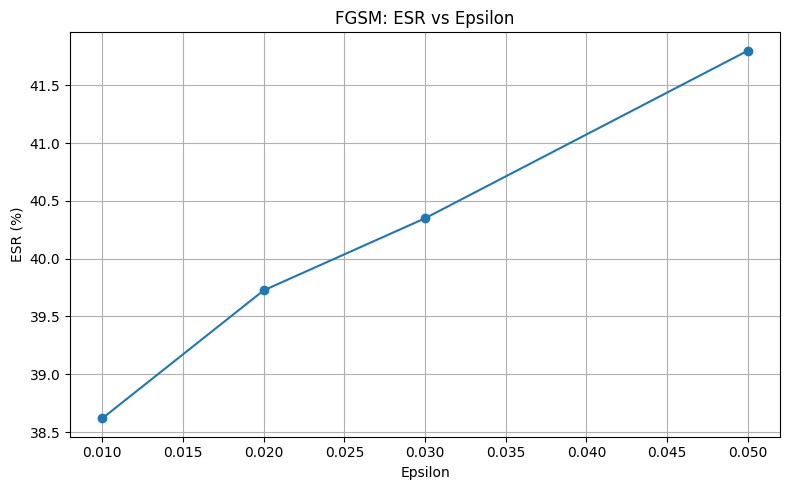

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(fgsm_sweep_results["Epsilon"], fgsm_sweep_results["ESR"], marker="o")
plt.xlabel("Epsilon")
plt.ylabel("ESR (%)")
plt.title("FGSM: ESR vs Epsilon")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{save_dir}/fgsm_esr_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
with open(f"{save_dir}/key_findings.txt", "w") as f:
    f.write("Best defended model: PGD-defended model\n")
    f.write("Baseline clean accuracy: 0.7933\n")
    f.write("PGD-defended on PGD accuracy: 0.7822\n")
    f.write("PGD-defended on PGD ESR: 32.59\n")
    f.write("FGSM sweep and PGD sweep completed\n")
    f.write("Hyperparameter tuning completed; best config = config_1\n")
    f.write("Paired t-test significant on clean and PGD test\n")

In [ ]:
print(type(X_train))

<class 'numpy.ndarray'>


In [ ]:
print(type(train))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(type(test))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
X_train_df = train.drop('label', axis=1)
X_test_df = test.drop('label', axis=1)

X_train_df, X_test_df = X_train_df.align(X_test_df, join='left', axis=1, fill_value=0)

feature_names = X_train_df.columns.tolist()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 122
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count']


In [ ]:
import numpy as np

protected_prefixes = ("protocol_type_", "service_", "flag_")

mask_1d = np.array([
    0 if col.startswith(protected_prefixes) else 1
    for col in feature_names
], dtype=np.float32)

print("Total features:", len(mask_1d))
print("Protected features:", int((mask_1d == 0).sum()))
print("Allowed features:", int((mask_1d == 1).sum()))

Total features: 122
Protected features: 84
Allowed features: 38


In [ ]:
feature_mask = mask_1d.reshape(1, len(mask_1d), 1).astype("float32")
print("Mask shape:", feature_mask.shape)


Mask shape: (1, 122, 1)


In [ ]:
protected_features = [col for col, m in zip(feature_names, mask_1d) if m == 0]
allowed_features = [col for col, m in zip(feature_names, mask_1d) if m == 1]

print("Protected feature examples:")
print(protected_features[:20])

print("\nAllowed feature examples:")
print(allowed_features[:20])

Protected feature examples:
['protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'service_eco_i', 'service_ecr_i', 'service_efs']

Allowed feature examples:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count']


In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy()

def fgsm_attack_masked(model, x, y, epsilon, feature_mask):
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)
    mask_tensor = tf.convert_to_tensor(feature_mask, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        prediction = model(x_tensor)
        loss = loss_object(y_tensor, prediction)

    gradient = tape.gradient(loss, x_tensor)
    masked_gradient = gradient * mask_tensor
    signed_grad = tf.sign(masked_gradient)

    x_adv = x_tensor + epsilon * signed_grad
    x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()


In [ ]:

def generate_masked_fgsm_full(model, X_data, y_data, epsilon, feature_mask, batch_size=128):
    adv_batches = []

    for i in range(0, len(X_data), batch_size):
        x_batch = X_data[i:i+batch_size]
        y_batch = y_data[i:i+batch_size]

        x_adv_batch = fgsm_attack_masked(
            model,
            x_batch,
            y_batch,
            epsilon=epsilon,
            feature_mask=feature_mask
        )
        adv_batches.append(x_adv_batch)

    return np.concatenate(adv_batches, axis=0).astype("float32")

In [ ]:
epsilon_masked = 0.01

X_test_fgsm_masked = generate_masked_fgsm_full(
    model,
    X_test_eval,
    y_test_eval,
    epsilon=epsilon_masked,
    feature_mask=feature_mask,
    batch_size=128
)

print("Masked FGSM test shape:", X_test_fgsm_masked.shape)

Masked FGSM test shape: (22544, 122, 1)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_prob_masked_fgsm = model.predict(X_test_fgsm_masked, batch_size=128, verbose=0).ravel()
y_pred_masked_fgsm = (y_prob_masked_fgsm > 0.5).astype("int32")

masked_fgsm_acc = accuracy_score(y_test_eval, y_pred_masked_fgsm)
masked_fgsm_prec = precision_score(y_test_eval, y_pred_masked_fgsm)
masked_fgsm_rec = recall_score(y_test_eval, y_pred_masked_fgsm)
masked_fgsm_f1 = f1_score(y_test_eval, y_pred_masked_fgsm)

attack_mask = (y_test_eval == 1)
masked_fgsm_esr = ((y_pred_masked_fgsm[attack_mask] == 0).sum() / attack_mask.sum()) * 100

cm_masked_fgsm = confusion_matrix(y_test_eval, y_pred_masked_fgsm)

print("Masked FGSM Accuracy:", masked_fgsm_acc)
print("Masked FGSM Precision:", masked_fgsm_prec)
print("Masked FGSM Recall:", masked_fgsm_rec)
print("Masked FGSM F1-score:", masked_fgsm_f1)
print("Masked FGSM ESR:", masked_fgsm_esr)
print(cm_masked_fgsm)


Masked FGSM Accuracy: 0.7468506032647267
Masked FGSM Precision: 0.9068280429321763
Masked FGSM Recall: 0.6188732174861685
Masked FGSM F1-score: 0.7356769024130425
Masked FGSM ESR: 38.11267825138315
[[8895  816]
 [4891 7942]]


In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy()

def pgd_attack_masked(model, x, y, epsilon=0.01, alpha=0.002, iterations=10, feature_mask=None):
    x_orig = tf.convert_to_tensor(x, dtype=tf.float32)
    x_adv = tf.identity(x_orig)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)
    mask_tensor = tf.convert_to_tensor(feature_mask, dtype=tf.float32)

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            prediction = model(x_adv)
            loss = loss_object(y_tensor, prediction)

        gradient = tape.gradient(loss, x_adv)
        masked_gradient = gradient * mask_tensor
        signed_grad = tf.sign(masked_gradient)

        x_adv = x_adv + alpha * signed_grad
        x_adv = tf.clip_by_value(x_adv, x_orig - epsilon, x_orig + epsilon)
        x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()

In [ ]:
def generate_masked_pgd_full(model, X_data, y_data, epsilon, alpha, iterations, feature_mask, batch_size=64):
    adv_batches = []

    for i in range(0, len(X_data), batch_size):
        x_batch = X_data[i:i+batch_size]
        y_batch = y_data[i:i+batch_size]

        x_adv_batch = pgd_attack_masked(
            model,
            x_batch,
            y_batch,
            epsilon=epsilon,
            alpha=alpha,
            iterations=iterations,
            feature_mask=feature_mask
        )
        adv_batches.append(x_adv_batch)

    return np.concatenate(adv_batches, axis=0).astype("float32")

In [ ]:
epsilon_masked_pgd = 0.01
alpha_masked_pgd = 0.002
iterations_masked_pgd = 10

X_test_pgd_masked = generate_masked_pgd_full(
    model,
    X_test_eval,
    y_test_eval,
    epsilon=epsilon_masked_pgd,
    alpha=alpha_masked_pgd,
    iterations=iterations_masked_pgd,
    feature_mask=feature_mask,
    batch_size=64
)

print("Masked PGD test shape:", X_test_pgd_masked.shape)

Masked PGD test shape: (22544, 122, 1)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_prob_masked_pgd = model.predict(X_test_pgd_masked, batch_size=128, verbose=0).ravel()
y_pred_masked_pgd = (y_prob_masked_pgd > 0.5).astype("int32")

masked_pgd_acc = accuracy_score(y_test_eval, y_pred_masked_pgd)
masked_pgd_prec = precision_score(y_test_eval, y_pred_masked_pgd)
masked_pgd_rec = recall_score(y_test_eval, y_pred_masked_pgd)
masked_pgd_f1 = f1_score(y_test_eval, y_pred_masked_pgd)

attack_mask = (y_test_eval == 1)
masked_pgd_esr = ((y_pred_masked_pgd[attack_mask] == 0).sum() / attack_mask.sum()) * 100

cm_masked_pgd = confusion_matrix(y_test_eval, y_pred_masked_pgd)

print("Masked PGD Accuracy:", masked_pgd_acc)
print("Masked PGD Precision:", masked_pgd_prec)
print("Masked PGD Recall:", masked_pgd_rec)
print("Masked PGD F1-score:", masked_pgd_f1)
print("Masked PGD ESR:", masked_pgd_esr)
print(cm_masked_pgd)

Masked PGD Accuracy: 0.7432132718239887
Masked PGD Precision: 0.9052001840773125
Masked PGD Recall: 0.6131068339437388
Masked PGD F1-score: 0.7310569105691057
Masked PGD ESR: 38.689316605626125
[[8887  824]
 [4965 7868]]


In [ ]:
import numpy as np

np.save("X_test_eval.npy", np.asarray(X_test).astype("float32"))
np.save("y_test_eval.npy", np.asarray(y_test).astype("int32").ravel())
np.save("feature_names.npy", np.array(feature_names, dtype=object))
np.save("mask_1d.npy", mask_1d)

final_results.round(4).to_csv("final_results.csv", index=False)
fgsm_sweep_results.to_csv("fgsm_epsilon_sweep.csv", index=False)
pgd_sweep_results.to_csv("pgd_epsilon_sweep.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

master_results = pd.DataFrame([
    {
        "Condition": "Baseline on clean",
        "Accuracy": 0.7669881121362677,
        "Precision": 0.9191729323308271,
        "Recall": 0.6477830593002416,
        "F1-score": 0.7599762307446176,
        "ESR": np.nan,
        "Confusion_Matrix": "[[8980, 731], [4520, 8313]]"
    },
    {
        "Condition": "Baseline on FGSM",
        "Accuracy": 0.7437908099724982,
        "Precision": 0.9061313700678707,
        "Recall": 0.6139881508610613,
        "F1-score": 0.7318591470779523,
        "ESR": 38.61918491389387,
        "Confusion_Matrix": "[[8895, 816], [4956, 7877]]"
    },
    {
        "Condition": "Baseline on PGD",
        "Accuracy": 0.7375354861595094,
        "Precision": 0.9222801302931596,
        "Recall": 0.6043793345281696,
        "F1-score": 0.7238788557562182,
        "ESR": 39.56206654718304,
        "Confusion_Matrix": "[[8871, 840], [5077, 7756]]"
    },
    {
        "Condition": "FGSM-defended on clean",
        "Accuracy": 0.749634492547906,
        "Precision": 0.9238845144356955,
        "Recall": 0.6034442453050729,
        "F1-score": 0.7300494932830545,
        "ESR": np.nan,
        "Confusion_Matrix": "[[9073, 638], [5089, 7744]]"
    },
    {
        "Condition": "FGSM-defended on FGSM",
        "Accuracy": 0.738999290276792,
        "Precision": 0.9217138002184732,
        "Recall": 0.591755630163641,
        "F1-score": 0.7207668944570995,
        "ESR": 40.824436998363595,
        "Confusion_Matrix": "[[9066, 645], [5239, 7594]]"
    },
    {
        "Condition": "FGSM-defended on PGD",
        "Accuracy": 0.7400195173882186,
        "Precision": 0.9217275586740866,
        "Recall": 0.5937037325644822,
        "F1-score": 0.7222143229536945,
        "ESR": 40.62962674355178,
        "Confusion_Matrix": "[[9064, 647], [5214, 7619]]"
    },
    {
        "Condition": "PGD-defended on clean",
        "Accuracy": 0.7519517388218595,
        "Precision": 0.9433084363903514,
        "Recall": 0.6003272812280839,
        "F1-score": 0.7337142857142858,
        "ESR": np.nan,
        "Confusion_Matrix": "[[9248, 463], [5129, 7704]]"
    },
    {
        "Condition": "PGD-defended on FGSM",
        "Accuracy": 0.7430801987224982,
        "Precision": 0.9204586169831601,
        "Recall": 0.600561053533858,
        "F1-score": 0.7268697538432519,
        "ESR": 39.9438946466142,
        "Confusion_Matrix": "[[9045, 666], [5126, 7707]]"
    },
    {
        "Condition": "PGD-defended on PGD",
        "Accuracy": 0.7438786373314408,
        "Precision": 0.923252188511812,
        "Recall": 0.5999376067184602,
        "F1-score": 0.7272813149442661,
        "ESR": 40.006233928153975,
        "Confusion_Matrix": "[[9071, 640], [5134, 7699]]"
    }
])

master_results

,Condition,Accuracy,Precision,Recall,F1-score,ESR,Confusion_Matrix
0,Baseline on clean,0.766988,0.919173,0.647783,0.759976,NaN,"[[8980, 731], [4520, 8313]]"
1,Baseline on FGSM,0.743791,0.906131,0.613988,0.731859,38.619185,"[[8895, 816], [4956, 7877]]"
2,Baseline on PGD,0.737535,0.922280,0.604379,0.723879,39.562067,"[[8871, 840], [5077, 7756]]"
3,FGSM-defended on clean,0.749634,0.923885,0.603444,0.730049,NaN,"[[9073, 638], [5089, 7744]]"
4,FGSM-defended on FGSM,0.738999,0.921714,0.591756,0.720767,40.824437,"[[9066, 645], [5239, 7594]]"
5,FGSM-defended on PGD,0.740020,0.921728,0.593704,0.722214,40.629627,"[[9064, 647], [5214, 7619]]"
6,PGD-defended on clean,0.751952,0.943308,0.600327,0.733714,NaN,"[[9248, 463], [5129, 7704]]"
7,PGD-defended on FGSM,0.743080,0.920459,0.600561,0.726870,39.943895,"[[9045, 666], [5126, 7707]]"
8,PGD-defended on PGD,0.743879,0.923252,0.599938,0.727281,40.006234,"[[9071, 640], [5134, 7699]]"


In [ ]:
master_results.to_csv(f"{save_dir}/master_results.csv", index=False)

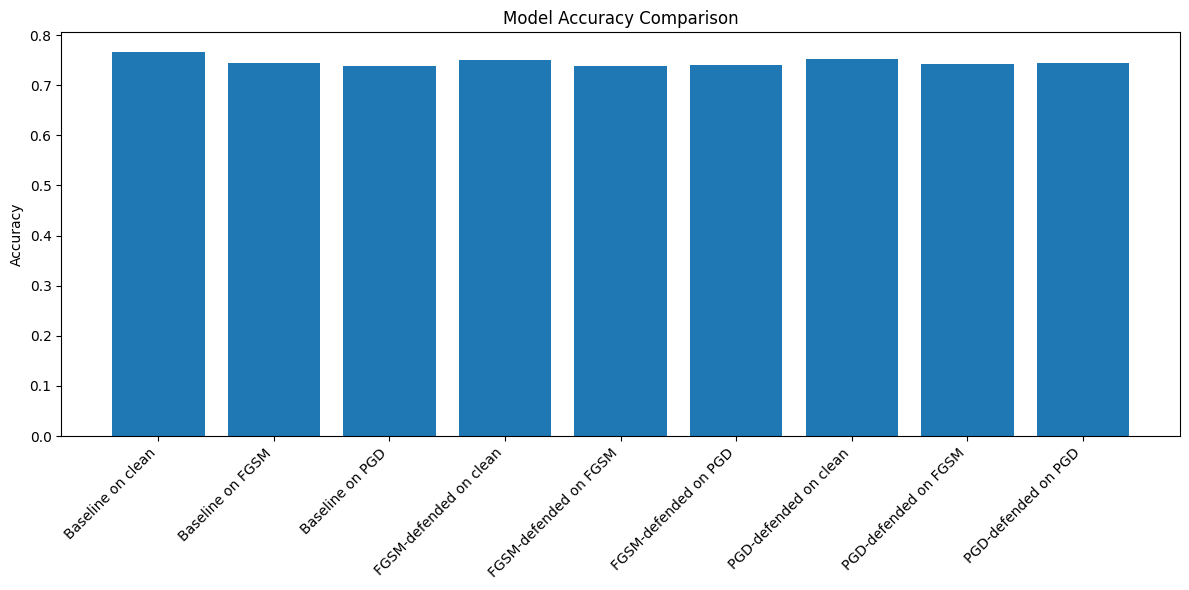

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(master_results["Condition"], master_results["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig(f"{save_dir}/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

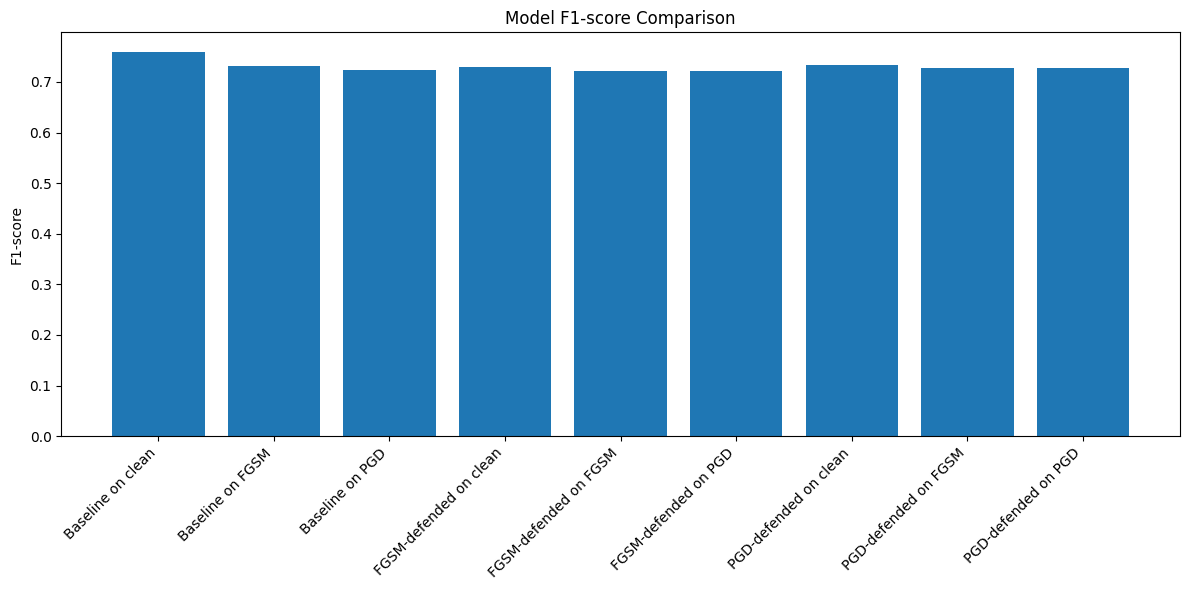

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(master_results["Condition"], master_results["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Model F1-score Comparison")
plt.tight_layout()
plt.savefig(f"{save_dir}/f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

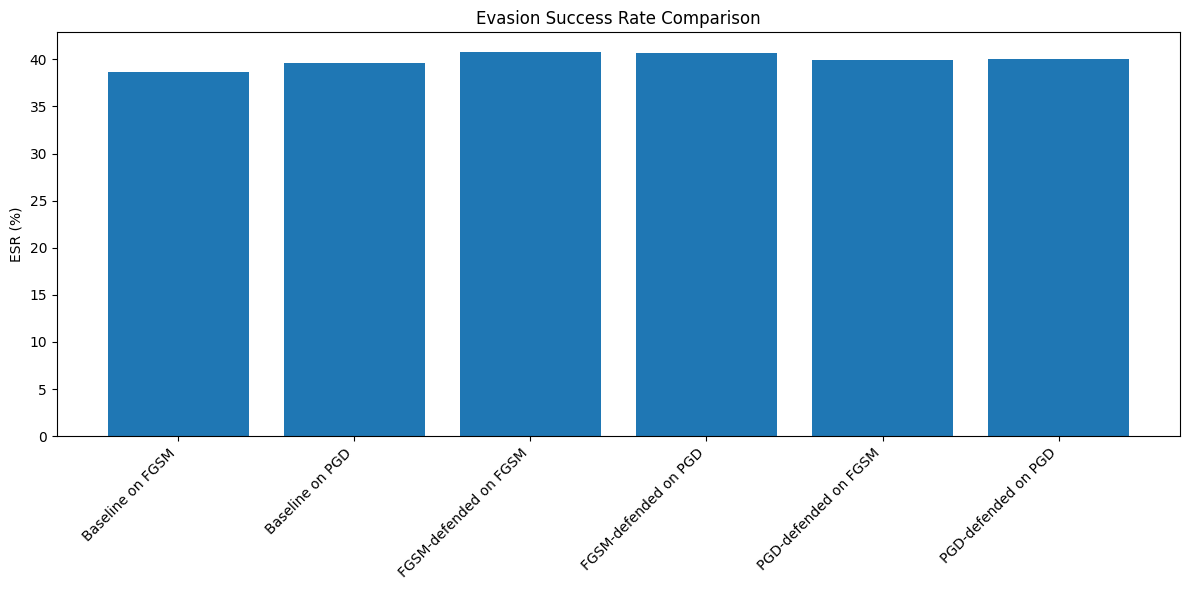

In [ ]:
esr_plot_df = master_results.dropna(subset=["ESR"])

plt.figure(figsize=(12,6))
plt.bar(esr_plot_df["Condition"], esr_plot_df["ESR"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ESR (%)")
plt.title("Evasion Success Rate Comparison")
plt.tight_layout()
plt.savefig(f"{save_dir}/esr_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:

cm_baseline_clean = np.array([[8980, 731], [4520, 8313]])
cm_baseline_fgsm = np.array([[8895, 816], [4956, 7877]])
cm_baseline_pgd = np.array([[8871, 840], [5077, 7756]])

cm_fgsm_def_fgsm = np.array([[9066, 645], [5239, 7594]])
cm_pgd_def_pgd = np.array([[9071, 640], [5134, 7699]])

cm_masked_pgd = np.array([[8887, 824], [4965, 7868]])

In [ ]:
def plot_conf_matrix(cm, title, filename):
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Normal", "Pred Attack"],
        yticklabels=["True Normal", "True Attack"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
import pandas as pd

masked_fgsm_comparison = pd.DataFrame([
    {
        "Attack_Type": "Unmasked FGSM",
        "Epsilon": 0.01,
        "Accuracy": 0.743967,
        "Precision": 0.906131,
        "Recall": 0.613808,
        "F1-score": 0.731859,
        "ESR": 38.619185
    },
    {
        "Attack_Type": "Masked FGSM",
        "Epsilon": 0.01,
        "Accuracy": 0.7468506032647267,
        "Precision": 0.9068280429321763,
        "Recall": 0.6188732174861685,
        "F1-score": 0.7356769024130425,
        "ESR": 38.11267825138315
    }
])

masked_pgd_comparison = pd.DataFrame([
    {
        "Attack_Type": "Unmasked PGD",
        "Epsilon": 0.01,
        "Accuracy": 0.737535,
        "Precision": 0.902280,
        "Recall": 0.604379,
        "F1-score": 0.723879,
        "ESR": 39.562067
    },
    {
        "Attack_Type": "Masked PGD",
        "Epsilon": 0.01,
        "Accuracy": 0.7432132718239887,
        "Precision": 0.9052001840773125,
        "Recall": 0.6131068339437388,
        "F1-score": 0.7316569105691057,
        "ESR": 38.689316605626125
    }
])

masked_fgsm_comparison


,Attack_Type,Epsilon,Accuracy,Precision,Recall,F1-score,ESR
0,Unmasked FGSM,0.01,0.743967,0.906131,0.613808,0.731859,38.619185
1,Masked FGSM,0.01,0.746851,0.906828,0.618873,0.735677,38.112678


In [ ]:
masked_fgsm_comparison.to_csv(f"{save_dir}/masked_fgsm_comparison.csv", index=False)
masked_pgd_comparison.to_csv(f"{save_dir}/masked_pgd_comparison.csv", index=False)

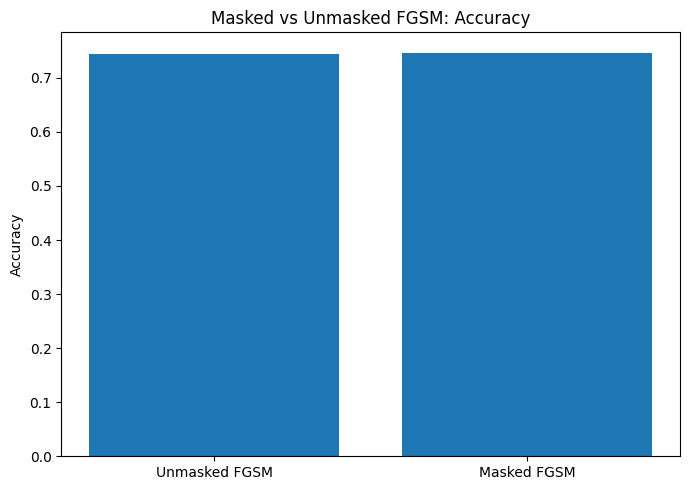

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(masked_fgsm_comparison["Attack_Type"], masked_fgsm_comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Masked vs Unmasked FGSM: Accuracy")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_fgsm_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

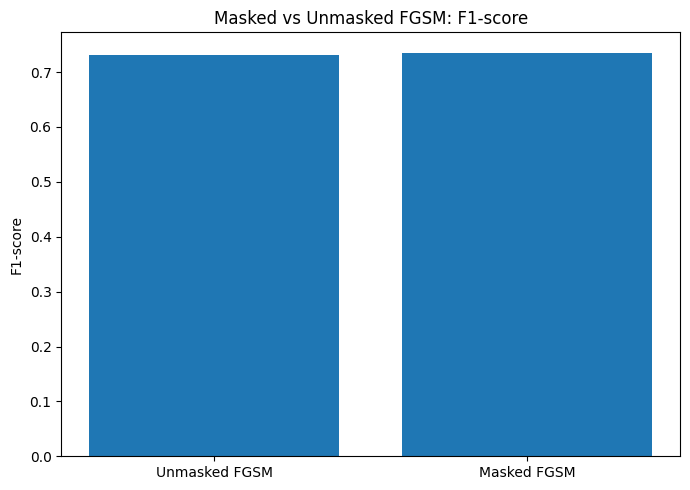

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(masked_fgsm_comparison["Attack_Type"], masked_fgsm_comparison["F1-score"])
plt.ylabel("F1-score")
plt.title("Masked vs Unmasked FGSM: F1-score")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_fgsm_f1.png", dpi=300, bbox_inches="tight")
plt.show()

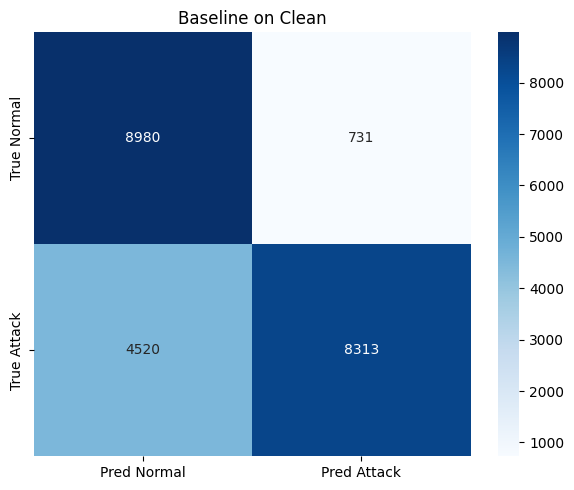

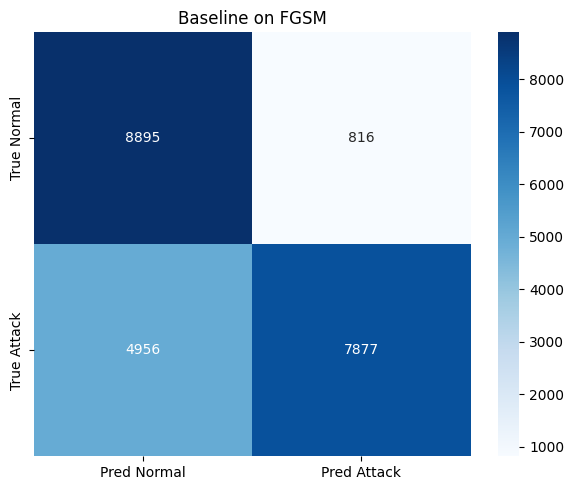

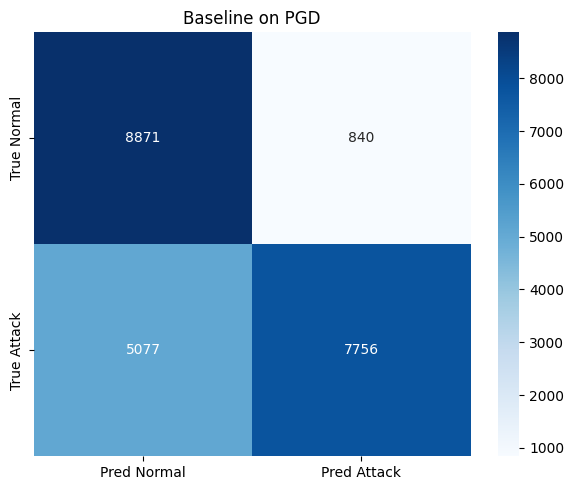

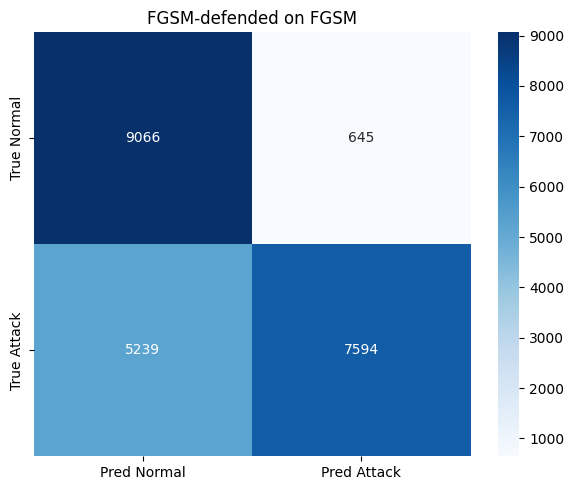

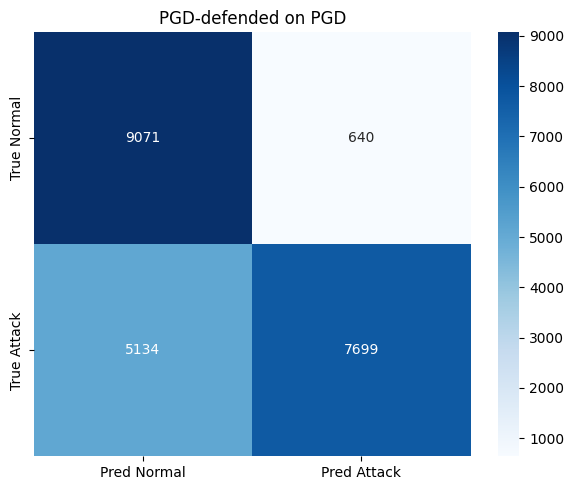

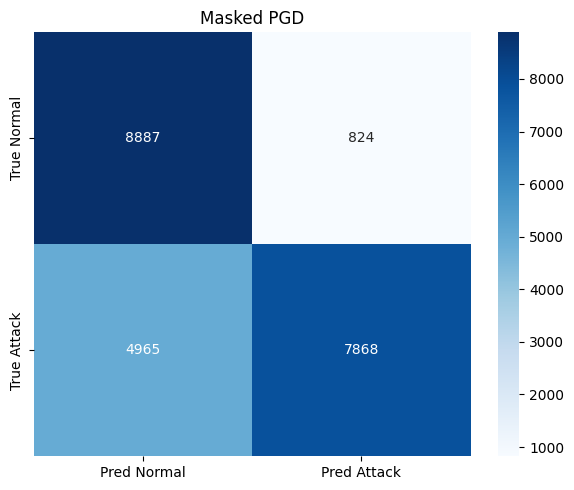

In [ ]:

plot_conf_matrix(cm_baseline_clean, "Baseline on Clean", "cm_baseline_clean.png")
plot_conf_matrix(cm_baseline_fgsm, "Baseline on FGSM", "cm_baseline_fgsm.png")
plot_conf_matrix(cm_baseline_pgd, "Baseline on PGD", "cm_baseline_pgd.png")

plot_conf_matrix(cm_fgsm_def_fgsm, "FGSM-defended on FGSM", "cm_fgsm_def_fgsm.png")
plot_conf_matrix(cm_pgd_def_pgd, "PGD-defended on PGD", "cm_pgd_def_pgd.png")

plot_conf_matrix(cm_masked_pgd, "Masked PGD", "cm_masked_pgd.png")

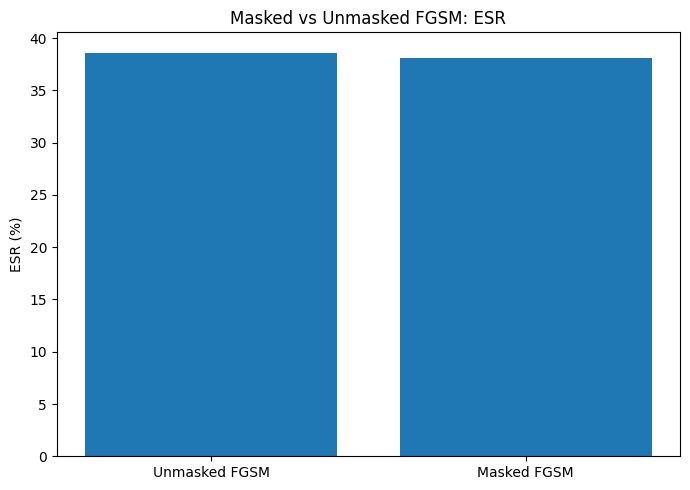

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(masked_fgsm_comparison["Attack_Type"], masked_fgsm_comparison["ESR"])
plt.ylabel("ESR (%)")
plt.title("Masked vs Unmasked FGSM: ESR")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_fgsm_esr.png", dpi=300, bbox_inches="tight")
plt.show()

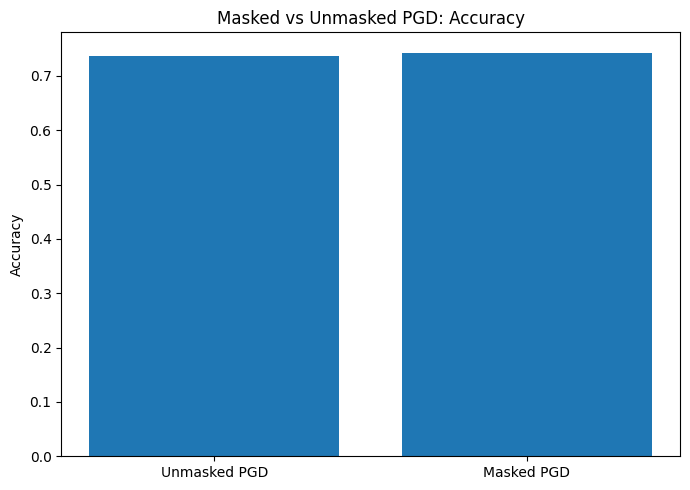

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(masked_pgd_comparison["Attack_Type"], masked_pgd_comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Masked vs Unmasked PGD: Accuracy")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_pgd_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

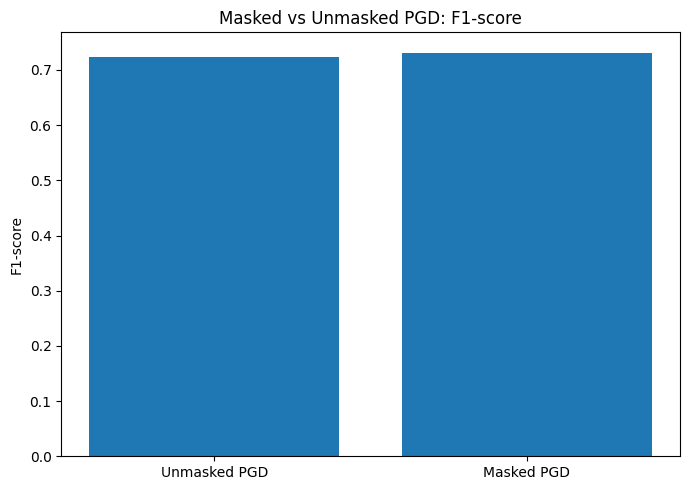

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(masked_pgd_comparison["Attack_Type"], masked_pgd_comparison["F1-score"])
plt.ylabel("F1-score")
plt.title("Masked vs Unmasked PGD: F1-score")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_pgd_f1.png", dpi=300, bbox_inches="tight")
plt.show()

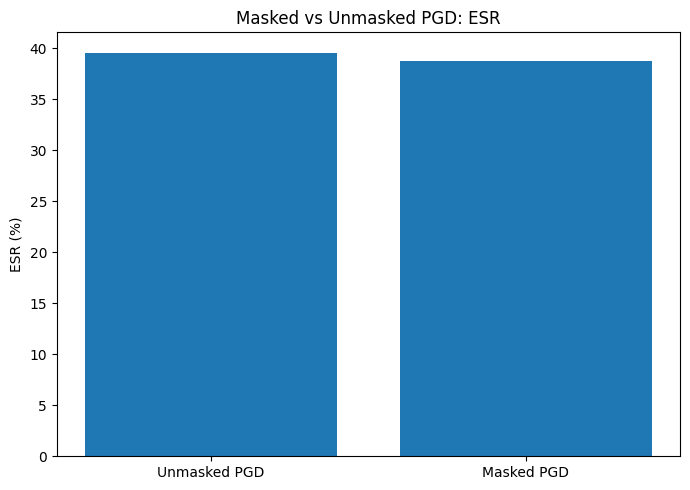

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(masked_pgd_comparison["Attack_Type"], masked_pgd_comparison["ESR"])
plt.ylabel("ESR (%)")
plt.title("Masked vs Unmasked PGD: ESR")
plt.tight_layout()
plt.savefig(f"{save_dir}/masked_vs_unmasked_pgd_esr.png", dpi=300, bbox_inches="tight")
plt.show()